# 02. ORE Snapshot and Its Abilities

This notebook shifts from a hand-built snapshot to a loader-backed snapshot built from a fresh ORE run. The goal is
to make the snapshot itself feel like the primary artifact: something you can inspect, audit, serialize, and hand to
both Python and ORE code without reopening the raw files.

**Purpose**
- show what the loader actually materializes
- keep the data fresh by generating the ORE outputs inside the notebook run
- introduce the stricter parity-grade `OreSnapshot` audit

**What you will learn**
- what comes back from `XVALoader.from_files(...)`
- how to inspect trades, quotes, netting, and generated XML without digging through the repo tree
- how to tell whether the resulting case is parity-ready


In [1]:
from pathlib import Path
import os
import sys

def _pythonorerunner_root(candidate: Path) -> bool:
    return (
        (candidate / "notebook_series" / "series_helpers.py").exists()
        and ((candidate / "pythonore").exists() or (candidate / "src" / "pythonore").exists())
    )

def _engine_root(candidate: Path) -> bool:
    return (candidate / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists()

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if _pythonorerunner_root(candidate) or _engine_root(candidate):
            return candidate
    repo_hint = Path("/Users/gordonlee/Documents/Engine")
    if _engine_root(repo_hint):
        return repo_hint
    standalone_hint = Path("/Users/gordonlee/Documents/PythonOreRunner")
    if _pythonorerunner_root(standalone_hint):
        return standalone_hint
    raise RuntimeError("Could not locate the notebook repo root from the current notebook working directory")

REPO_ROOT = _find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "notebook_series" if _pythonorerunner_root(REPO_ROOT) else REPO_ROOT / "Tools" / "PythonOreRunner" / "notebook_series"
for path in (NOTEBOOK_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import series_helpers as nh

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

repo = nh.bootstrap_notebook_env(REPO_ROOT)
nh.apply_plot_style()
print(repo)


/Users/gordonlee/Documents/PythonOreRunner


XVA: Build Cube 1 x 121 x 500                                                                   Classic valuation summary [s]: update=0.00, calibration=0.00, initScenario=0.00, qlUpdate=0.00, calculator=0.00, cpty=0.00, fixing=0.00
SimMarket update summary [s]: pre=0.00, date=0.00, scenarioFetch=0.00, applyScenario=0.00, refresh=0.00, fixings=0.00, asd=0.00
Source ORE xml: /Users/gordonlee/Documents/PythonOreRunner/Examples/Exposure/Input/ore_measure_lgm_fixed.xml
Input dir: /Users/gordonlee/Documents/PythonOreRunner/Examples/Exposure/Input
Output dir: /Users/gordonlee/Documents/PythonOreRunner/Examples/Exposure/Output/measure_lgm_fixed
OreSnapshotApp elapsed (s): 0.3943


,component,count,notes
0,market quotes,7881,2016-02-05
1,fixings,5454,file
2,trades,1,file
3,netting sets,3,EUR
4,collateral balances,0,2016-02-05
5,analytics,1,CVA


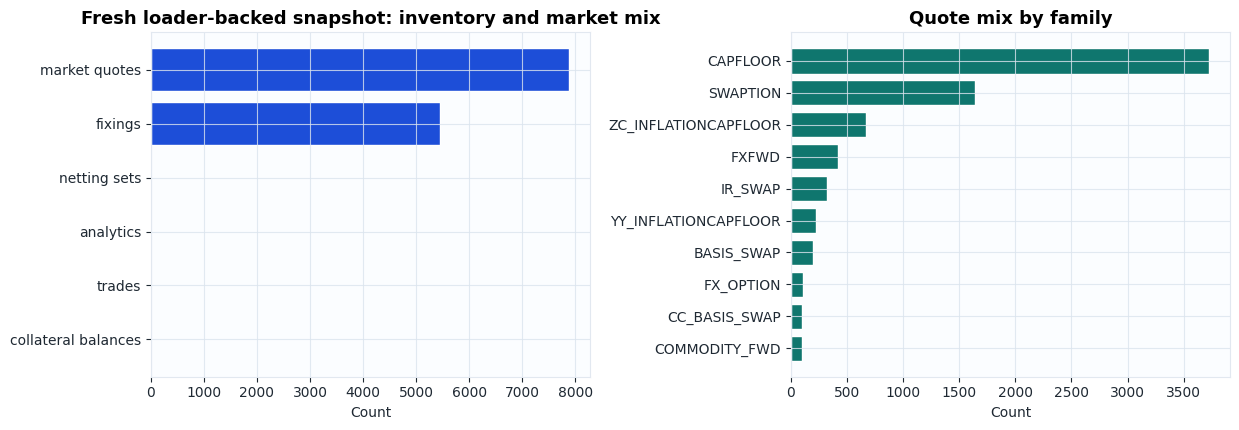

In [2]:
from dataclasses import replace

from native_xva_interface import (
    CollateralBalance,
    CollateralConfig,
    FixingPoint,
    FixingsData,
    MarketData,
    MarketQuote,
    NettingConfig,
    NettingSet,
    XVAConfig,
    map_snapshot,
    DeterministicToyAdapter,
)
from py_ore_tools import validate_xva_snapshot_dataclasses, xva_snapshot_validation_dataframe

# Load an existing repo case, then run the canonical in-memory OreSnapshotApp on buffers.
source_ore_xml = nh.default_live_parity_ore_xml()
snapshot, ore_snapshot, case_meta = nh.load_case_snapshots(source_ore_xml)
app_result, app_meta = nh.run_ore_snapshot_app_case(source_ore_xml, engine="compare", price=True, xva=True, paths=500)
mapped = map_snapshot(snapshot)

print("Source ORE xml:", case_meta["ore_xml"])
print("Input dir:", case_meta["input_dir"])
print("Output dir:", case_meta["output_dir"])
print("OreSnapshotApp elapsed (s):", round(app_meta["elapsed_sec"], 4))
display(nh.snapshot_overview(snapshot))
nh.plot_snapshot_composition(snapshot, title="Fresh loader-backed snapshot: inventory and market mix")


## Inputs we reuse from the repo

The notebook starts from a repo-backed ORE case and uses the canonical in-memory `OreSnapshotApp` surface for the
parity workflow. That keeps the demonstration programmatic and avoids creating persistent notebook output folders.

The loader-backed path still follows the same code used in the tests and demos:
- `native_xva_interface/loader.py`
- `native_xva_interface/tests/test_step2_loader.py`
- `native_xva_interface/tests/test_step3_merge.py`


,trade_id,trade_type,counterparty,netting_set,product_type,currency_or_pair,notional,maturity_years
0,Swap_20,Swap,CPTY_A,CPTY_A,IRS,EUR,10000000.0,20.0


,netting_set_id,counterparty,active_csa,csa_currency,threshold_pay,threshold_receive
0,CPTY_A,None,False,EUR,0.0,0.0
1,CPTY_B,None,False,EUR,0.0,0.0
2,CPTY_C,None,False,EUR,0.0,0.0


""


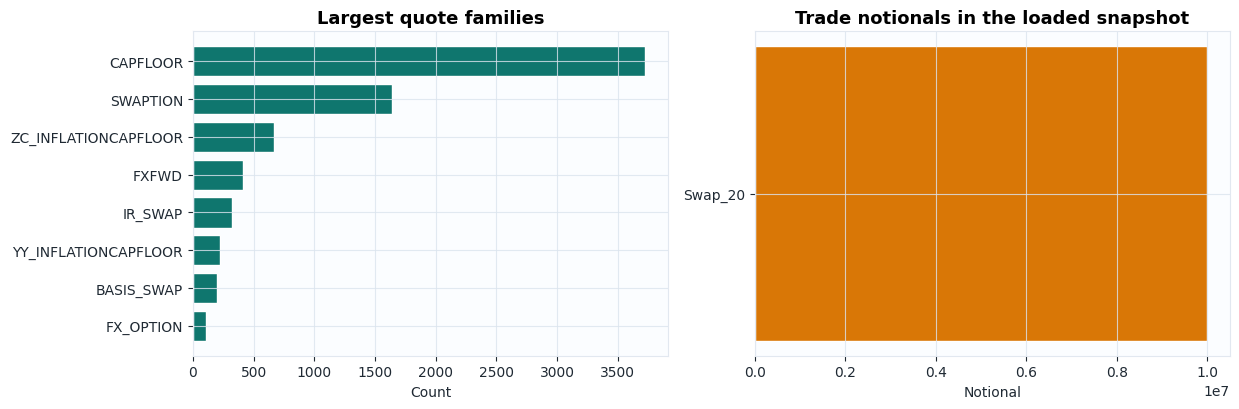

In [3]:
trade_df = nh.trade_frame(snapshot)
display(trade_df.head(12))
display(nh.netting_frame(snapshot).head(12))
display(nh.collateral_frame(snapshot).head(12))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
nh.plot_ranked_bars(nh.quote_family_frame(snapshot), "family", "count", title="Largest quote families", color=nh.PALETTE["teal"], top_n=8, ax=axes[0])
nh.plot_ranked_bars(trade_df, "trade_id", "notional", title="Trade notionals in the loaded snapshot", color=nh.PALETTE["gold"], ax=axes[1])
plt.tight_layout()
plt.show()
plt.close(fig)


## Snapshot as a reusable artifact

The loader has already normalized XML, market text, fixings, and netting configuration into one object. That is the
practical value of the snapshot: most downstream code can stop caring which original file carried which piece.


{
  "collateral": {
    "balances": [],
    "source_meta": {
      "origin": "file",
      "path": "/Users/gordonlee/Documents/PythonOreRunner/Examples/Exposure/Input/collateralbalances.xml"
    }
  },
  "config": {
    "analytics": [
      "CVA"
    ],
    "asof": "2016-02-05",
    "base_currency": "EUR",
    "horizon_years": 5,
    "mpor": {
      "cashflow_mode": "NonePay",
      "closeout_lag_period": "0W",
      "enabled": false,
      "mpor_days": 0,
      "mpor_years": 0.0,
      "source": "disabled",
      "sticky": true
    },
    "num_paths": 5000,
    "params": {
      "asofDate": "2016-02-05",
      "calendarAdjustment": "../../Input/calendaradjustment.xml",
      "continueOnError": "false",
      "conventionsFile": "../../Input/conventions.xml",
      "curveConfigFile": "../../Input/curveconfig.xml",
      "fixingDataFile": "../../Input/fixings_20160205.txt",
      "implyTodaysFixings": "Y",
      "inputPath": "Input",
      "logFile": "log.txt",
      "logMask": "31",
   

,field,value
0,asof,2016-02-05
1,base_currency,EUR
2,analytics,CVA
3,market_data_lines,7881
4,fixing_data_lines,5454
5,xml_buffers,9


,xml_name,chars,root_tag
0,collateralbalances.xml,42,CollateralBalances
1,conventions.xml,52729,Conventions
2,counterparty.xml,68,CounterpartyInformation
3,curveconfig.xml,131522,CurveConfiguration
4,netting.xml,3428,NettingSetDefinitions
5,portfolio.xml,2128,Portfolio
6,pricingengine.xml,15298,PricingEngines
7,simulation.xml,10092,Simulation
8,todaysmarket.xml,13743,TodaysMarket


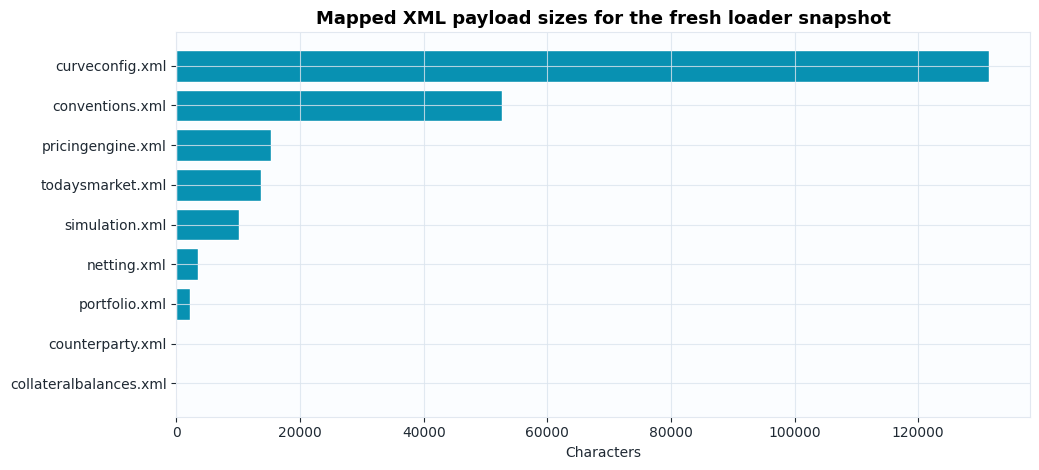

In [4]:
snapshot_dict = snapshot.to_dict()
snapshot_json = nh.to_pretty_json(snapshot_dict, limit=1800)
print(snapshot_json)

display(nh.mapped_input_summary(mapped))
display(nh.xml_buffer_summary(mapped).head(12))
nh.plot_xml_buffer_sizes(mapped, title="Mapped XML payload sizes for the fresh loader snapshot")


## Canonical ORE app run without persistent notebook outputs

The same case can be run through the buffer-based `OreSnapshotApp` API. It materializes the case in a temporary
workspace internally, returns the comparison and validation payloads to Python, and leaves no new repo artifacts
behind.


In [5]:
display(nh.ore_snapshot_app_summary_frame(app_result))
display(pd.DataFrame(app_result.comparison_rows))
display(pd.DataFrame(app_result.input_validation_rows).head(12))


,field,value
0,trade_id,Swap_20
1,counterparty,CPTY_A
2,netting_set_id,CPTY_A
3,paths,
4,seed,
5,rng_mode,
6,py_t0_npv,602.342182
7,ore_t0_npv,602.485572
8,py_cva,54265.901071
9,ore_cva,55680.51


,section,field,value
0,pricing,ore_t0_npv,602.485572
1,pricing,py_t0_npv,602.3421823545359
2,pricing,t0_npv_abs_diff,0.1433896454641399
3,pricing,leg_source,flows
4,pricing,discount_column,EUR-EURIBOR-6M
5,pricing,forward_column,EUR-EURIBOR-6M
6,xva,ore_cva,55680.51
7,xva,py_cva,54265.90107068666
8,xva,cva_rel_diff,0.025405818468856353
9,xva,ore_dva,84270.27


,section,field,value
0,market_configurations,requested,"['libor', 'default']"
1,market_configurations,available,"['collateral_inccy', 'default', 'libor', 'xois..."
2,market_configurations,missing_requested,[]
3,market_configurations,valid,True
4,todaysmarket_sections,missing_references,[]
5,todaysmarket_sections,valid,True
6,curve_specs,active_curve_ids_by_section,"{'YieldCurves': ['BANK_EUR_BORROW', 'BANK_EUR_..."
7,curve_specs,quote_scope_curve_ids_by_section,"{'YieldCurves': ['EUR1D', 'EUR6M']}"
8,curve_specs,invalid,[]
9,curve_specs,valid,True


## Parity completeness audit

A runtime snapshot being usable is not the same thing as a case being parity-ready. The `OreSnapshot` audit is more
strict: it checks whether the run captured enough schedule, curve, credit, funding, and exposure information for a
fair Python-vs-ORE comparison.


,section,field,value
0,trade_setup,complete,True
1,trade_setup,fixed_leg_count,20
2,trade_setup,float_leg_count,40
3,curve_setup,complete,True
4,curve_setup,discount_column,EUR-EURIBOR-6M
5,curve_setup,forward_column,EUR-EURIBOR-6M
6,curve_setup,xva_discount_column,EUR-EURIBOR-6M
7,curve_setup,borrowing_curve_column,BANK_EUR_BORROW
8,curve_setup,lending_curve_column,BANK_EUR_LEND
9,curve_setup,discount_points,241


Parity issues: []
Parity ready: True


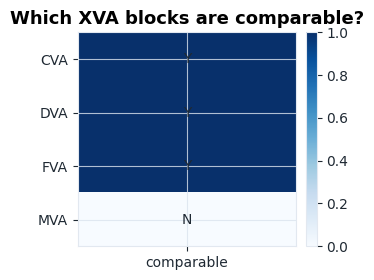

In [6]:
if ore_snapshot is not None:
    parity_report = ore_snapshot.parity_completeness_report()
    parity_df = ore_snapshot.parity_completeness_dataframe()
    display(parity_df)
    print("Parity issues:", parity_report["issues"])
    print("Parity ready:", parity_report["parity_ready"])
    comparability_df = parity_df[parity_df["section"] == "comparability"].copy()
    comparability_df["comparable"] = comparability_df["value"].astype(bool)
    nh.plot_boolean_matrix(comparability_df, row_col="field", value_cols=["comparable"], title="Which XVA blocks are comparable?")
else:
    print("No parity-grade OreSnapshot audit available for this loader bundle.")


The audit table is the one to trust when you want to compare engines. It separates “the case runs” from “the case is
economically lined up well enough to compare specific XVA numbers.”


## File-backed validation as a fix list

The XML/file validator is meant to answer a more operational question: if the case is not linked up cleanly,
what exactly should be changed next? The report below is shown as a fix list rather than a generic status dump.


In [7]:
from py_ore_tools import validate_ore_input_snapshot, ore_input_validation_dataframe

file_validation = validate_ore_input_snapshot(case_meta["ore_xml"])
file_validation_df = ore_input_validation_dataframe(file_validation)
display(file_validation_df[file_validation_df["section"] == "action_items"])

print("Input links valid:", file_validation["input_links_valid"])
for item in file_validation.get("action_items", []):
    print(f"[{item['severity']}] {item['code']}")
    print("  failed :", item["what_failed"])
    print("  fix    :", item["what_to_fix"])
    print("  where  :", ", ".join(str(x) for x in item.get("where_to_fix", [])))


,section,field,value
30,action_items,0:code,missing_mandatory_quotes
31,action_items,0:severity,error
32,action_items,0:what_failed,The active curve build requests mandatory quot...
33,action_items,0:what_to_fix,Add these quote ids for the asof date to the m...
34,action_items,0:where_to_fix,[/Users/gordonlee/Documents/PythonOreRunner/Ex...


Input links valid: False
[error] missing_mandatory_quotes
  failed : The active curve build requests mandatory quote ids that are not present in the market data on the asof date.
  fix    : Add these quote ids for the asof date to the market data file, or change the active curve configuration so it stops requesting them, or mark genuinely optional quotes as optional in curveconfig.xml.
  where  : /Users/gordonlee/Documents/PythonOreRunner/Examples/Input/curveconfig.xml, /Users/gordonlee/Documents/PythonOreRunner/Examples/Input/market_20160205_flat.txt


## Dataclass validation: good and bad examples

The file-backed validator checks the ORE XML chain. There is now a second validator for the in-memory dataclasses
themselves. That matters when snapshots are built programmatically, merged, or modified before any engine run.

The good example below is a deliberately well-formed programmatic snapshot. The fresh loader-backed snapshot above
is useful for inspection, but it is not a clean teaching example for this validator because loader bundles can be
operationally valid while still failing stricter in-memory consistency checks.

The bad example breaks a few basic contracts on purpose:
- quote date no longer matches the snapshot asof
- a fixing is placed after the asof date
- the trade references a netting set that is not defined
- collateral references another unknown netting set
- analytics includes an unsupported metric


In [8]:
good_snapshot = nh.make_programmatic_snapshot(num_paths=128)
good_report = validate_xva_snapshot_dataclasses(good_snapshot)
good_df = xva_snapshot_validation_dataframe(good_report)
print("Good snapshot valid:", good_report["snapshot_valid"])
print("Good snapshot issues:", good_report["issues"])
display(good_df)
display(good_df[good_df["section"] == "action_items"])


Good snapshot valid: True
Good snapshot issues: []


,section,field,value
0,market,market_asof,2026-03-08
1,market,config_asof,2026-03-08
2,market,quote_dates,[2026-03-08]
3,market,quote_duplicate_count,0
4,market,quote_key_count,4
5,fixings,dates,"[2026-03-06, 2026-03-07]"
6,fixings,count,2
7,portfolio,trade_ids,"[IRS_DEMO_1, FXFWD_DEMO_1]"
8,portfolio,counterparties,[CP_A]
9,portfolio,netting_sets,[NS_EUR]


,section,field,value


In [9]:
bad_snapshot = replace(
    good_snapshot,
    market=replace(
        good_snapshot.market,
        raw_quotes=(
            MarketQuote(
                date="1999-01-01",
                key=good_snapshot.market.raw_quotes[0].key,
                value=good_snapshot.market.raw_quotes[0].value,
            ),
        ) if good_snapshot.market.raw_quotes else (
            MarketQuote(date="1999-01-01", key="FX/RATE/EUR/USD", value=1.10),
        ),
    ),
    fixings=FixingsData(
        points=(FixingPoint(date="2099-01-01", index="USD-LIBOR-3M", value=0.05),)
    ),
    portfolio=replace(
        good_snapshot.portfolio,
        trades=(
            replace(good_snapshot.portfolio.trades[0], netting_set="BROKEN_NS"),
        ) if good_snapshot.portfolio.trades else good_snapshot.portfolio.trades,
    ),
    netting=NettingConfig(netting_sets={"NS_OK": NettingSet(netting_set_id="NS_OK", counterparty="CP_A")}),
    collateral=CollateralConfig(balances=(CollateralBalance(netting_set_id="BROKEN_COLLATERAL", currency=good_snapshot.config.base_currency),)),
    config=replace(good_snapshot.config, analytics=("CVA", "NOT_A_METRIC")),
)

bad_report = validate_xva_snapshot_dataclasses(bad_snapshot)
bad_df = xva_snapshot_validation_dataframe(bad_report)
print("Bad snapshot valid:", bad_report["snapshot_valid"])
print("Bad snapshot issues:", bad_report["issues"])
display(bad_df)
display(bad_df[bad_df["section"] == "action_items"])
for item in bad_report.get("action_items", []):
    print(f"[{item['severity']}] {item['code']}")
    print("  failed :", item["what_failed"])
    print("  fix    :", item["what_to_fix"])
    print("  where  :", ", ".join(str(x) for x in item.get("where_to_fix", [])))


Bad snapshot valid: False
Bad snapshot issues: ['some market quotes are not dated on the market asof', 'some fixings are dated after the snapshot asof', 'config.analytics contains unsupported metrics or is empty', 'some trade netting sets are missing from netting config', 'some collateral balances reference unknown netting sets']


,section,field,value
0,market,market_asof,2026-03-08
1,market,config_asof,2026-03-08
2,market,quote_dates,[1999-01-01]
3,market,quote_duplicate_count,0
4,market,quote_key_count,1
5,fixings,dates,[2099-01-01]
6,fixings,count,1
7,portfolio,trade_ids,[IRS_DEMO_1]
8,portfolio,counterparties,[CP_A]
9,portfolio,netting_sets,[BROKEN_NS]


,section,field,value
23,action_items,0:code,quote_date_mismatch
24,action_items,0:severity,error
25,action_items,0:what_failed,Some market quotes carry a date different from...
26,action_items,0:what_to_fix,Either restamp those MarketQuote.date values t...
27,action_items,0:where_to_fix,[snapshot.market.raw_quotes[*].date]
28,action_items,1:code,fixings_after_asof
29,action_items,1:severity,error
30,action_items,1:what_failed,Some fixing dates are later than the snapshot ...
31,action_items,1:what_to_fix,Remove future fixings or move the snapshot aso...
32,action_items,1:where_to_fix,"[snapshot.fixings.points[*].date, snapshot.con..."


[error] quote_date_mismatch
  failed : Some market quotes carry a date different from snapshot.market.asof.
  fix    : Either restamp those MarketQuote.date values to the snapshot asof or move them into a snapshot whose asof matches the quote date.
  where  : snapshot.market.raw_quotes[*].date
[error] fixings_after_asof
  failed : Some fixing dates are later than the snapshot asof date.
  fix    : Remove future fixings or move the snapshot asof forward so the fixings are historical or same-day.
  where  : snapshot.fixings.points[*].date, snapshot.config.asof
[error] unsupported_analytics
  failed : The analytics tuple contains unsupported metric names or no metrics at all.
  fix    : Use only supported metrics: CVA, DVA, FVA, MVA.
  where  : snapshot.config.analytics
[error] missing_netting_sets
  failed : Some trades reference netting sets that are not defined in snapshot.netting.netting_sets.
  fix    : Add the missing NettingSet objects to snapshot.netting.netting_sets or change the

In [10]:
# One cheap engine pass shows that the fresh snapshot is immediately executable from Python.
toy_result, toy_elapsed = nh.run_adapter(snapshot, DeterministicToyAdapter())
print(f"Deterministic toy run elapsed: {toy_elapsed:.4f}s")
display(nh.result_metrics_frame(toy_result))


Deterministic toy run elapsed: 0.0337s


,metric,value
0,PV,2000000.0
1,CVA,8520.0
2,XVA_TOTAL,8520.0


## Key takeaways

- The snapshot is the cleanest inspection boundary in the current Python-facing stack.
- The canonical `OreSnapshotApp` path keeps the notebook run in-memory and avoids new persistent output folders.
- The parity audit is the right place to decide what can be compared, not an afterthought.

## Where this connects next

The next notebook zooms into the market side: curve extraction, curve fitting, and how those outputs feed the LGM model.
